In [1]:
!git clone https://github.com/tarekmahfoudi/medical-document-ocr-extraction.git

Cloning into 'medical-document-ocr-extraction'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 83 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 4.47 MiB | 11.19 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [2]:
import os

project_path = "/content/medical-document-ocr-extraction"
sample_path = os.path.join(project_path, "data", "raw", "sample")

print(os.listdir(sample_path))

['med_doc_bill_100401_noisy.jpg', 'med_doc_discharge_summary_200434_noisy.jpg', 'med_doc_bill_100407_noisy.jpg', 'med_doc_discharge_summary_200435_noisy.jpg', 'med_doc_discharge_summary_200436_noisy.jpg', 'med_doc_discharge_summary_200429_noisy.jpg', '.gitkeep', 'med_doc_discharge_summary_200432_noisy.jpg', 'med_doc_discharge_summary_200439_noisy.jpg', 'med_doc_discharge_summary_200433_noisy.jpg', 'med_doc_bill_100402_noisy.jpg', 'med_doc_bill_100409_noisy.jpg', 'med_doc_bill_100498_noisy.jpg', 'med_doc_bill_100499_noisy.jpg', 'med_doc_bill_100400_noisy.jpg', 'med_doc_discharge_summary_200431_noisy.jpg', 'med_doc_bill_100408_noisy.jpg', 'med_doc_discharge_summary_200428_noisy.jpg', 'med_doc_discharge_summary_200430_noisy.jpg', 'med_doc_bill_100403_noisy.jpg', 'med_doc_bill_100406_noisy.jpg']


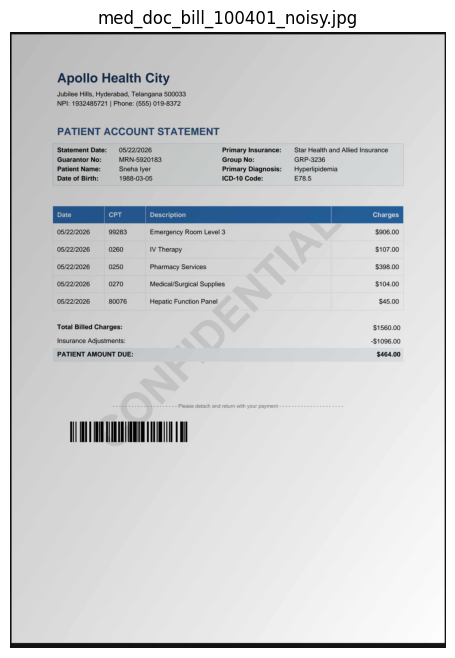

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

image_files = [f for f in os.listdir(sample_path) if f.endswith(".jpg")]

first_image_path = os.path.join(sample_path, image_files[0])

img = Image.open(first_image_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title(image_files[0])
plt.show()

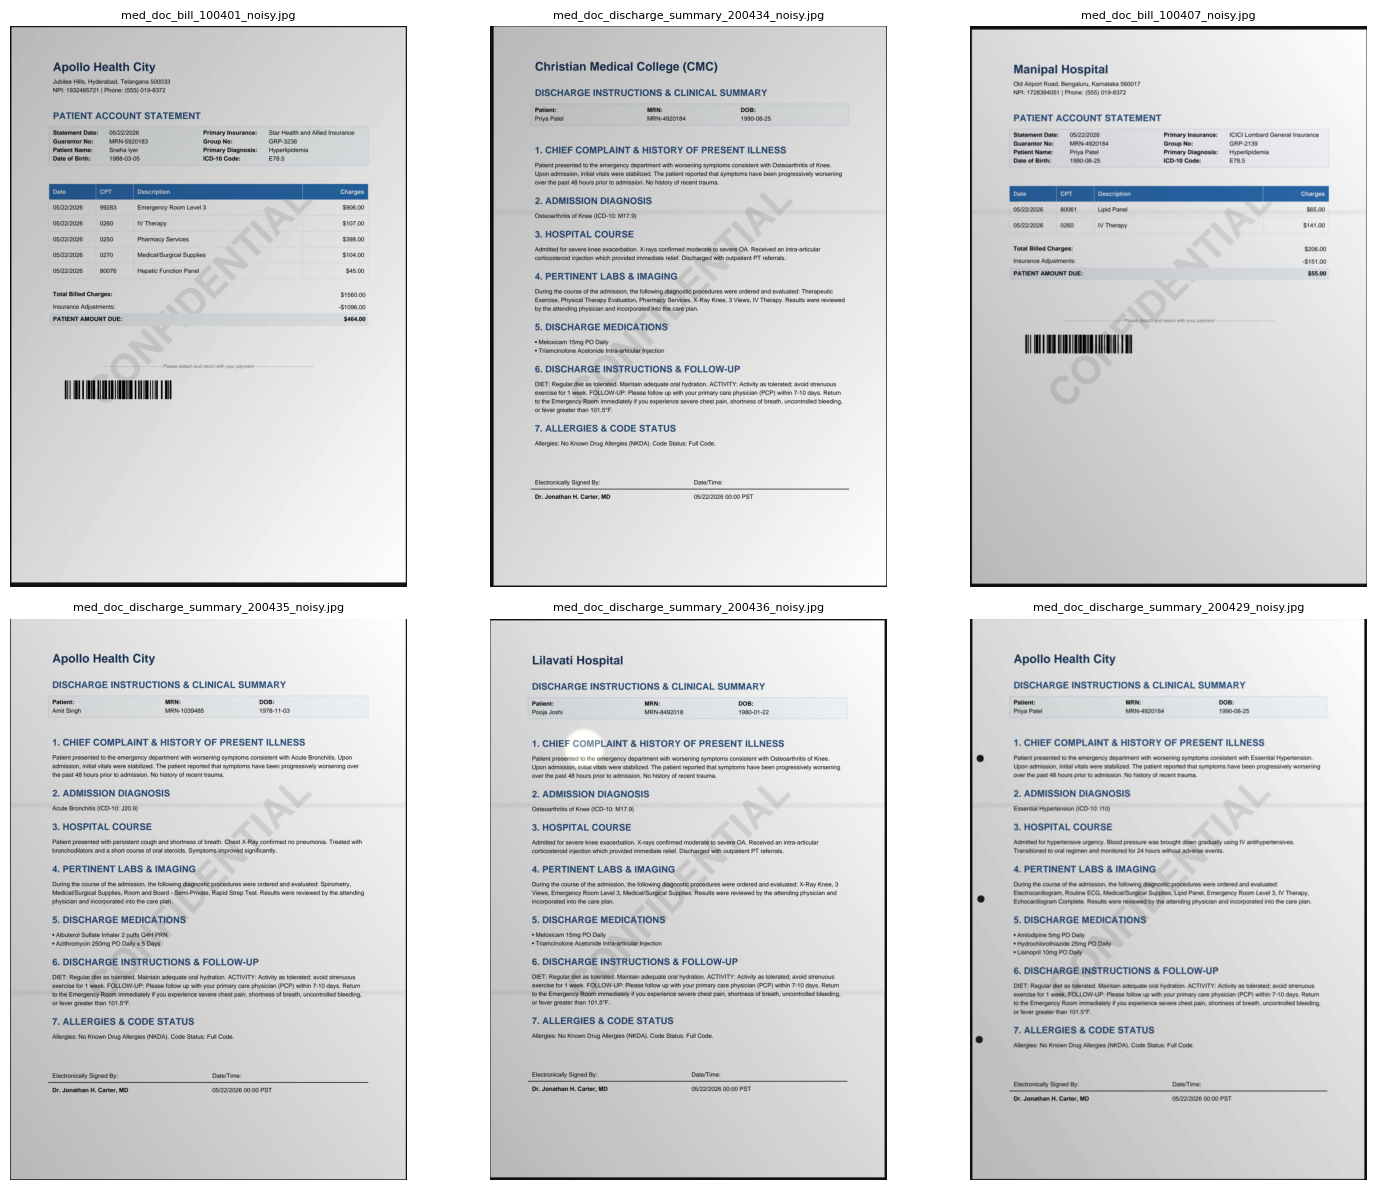

In [10]:
plt.figure(figsize=(15, 12))

for i, filename in enumerate(image_files[:6]):
    image_path = os.path.join(sample_path, filename)
    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(filename, fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
image_info = []

for filename in image_files:
    image_path = os.path.join(sample_path, filename)
    img = Image.open(image_path)

    image_info.append({
        "filename": filename,
        "width": img.width,
        "height": img.height,
        "mode": img.mode
    })

image_info[:5]

[{'filename': 'med_doc_bill_100401_noisy.jpg',
  'width': 1654,
  'height': 2339,
  'mode': 'RGB'},
 {'filename': 'med_doc_discharge_summary_200434_noisy.jpg',
  'width': 1654,
  'height': 2339,
  'mode': 'RGB'},
 {'filename': 'med_doc_bill_100407_noisy.jpg',
  'width': 1654,
  'height': 2339,
  'mode': 'RGB'},
 {'filename': 'med_doc_discharge_summary_200435_noisy.jpg',
  'width': 1654,
  'height': 2339,
  'mode': 'RGB'},
 {'filename': 'med_doc_discharge_summary_200436_noisy.jpg',
  'width': 1654,
  'height': 2339,
  'mode': 'RGB'}]

In [12]:
import pandas as pd

df_images = pd.DataFrame(image_info)
df_images

,filename,width,height,mode
0,med_doc_bill_100401_noisy.jpg,1654,2339,RGB
1,med_doc_discharge_summary_200434_noisy.jpg,1654,2339,RGB
2,med_doc_bill_100407_noisy.jpg,1654,2339,RGB
3,med_doc_discharge_summary_200435_noisy.jpg,1654,2339,RGB
4,med_doc_discharge_summary_200436_noisy.jpg,1654,2339,RGB
5,med_doc_discharge_summary_200429_noisy.jpg,1654,2339,RGB
6,med_doc_discharge_summary_200432_noisy.jpg,1654,2339,RGB
7,med_doc_discharge_summary_200439_noisy.jpg,1654,2339,RGB
8,med_doc_discharge_summary_200433_noisy.jpg,1654,2339,RGB
9,med_doc_bill_100402_noisy.jpg,1654,2339,RGB


## First observations

The sample contains noisy medical document images from the Kaggle dataset "Noisy Medical Document Images (OCR)".

The images include different document types such as medical bills and discharge summaries.

The documents are already available as scanned-like JPG images, so the next step is not image generation but image preprocessing before OCR.

Potential OCR difficulties:
- noise in the background;
- small text;
- possible low contrast;
- document layout variability;
- tables and structured sections.